# Text JEPA + Diffusion Decoder — v5 (correct architecture)

## What was wrong in v3/v4

In both previous versions, `TextPredictor` owned its own tokenizer + BERT encoder
and was doing `text → tokenize → encode → project`. That makes it a second
full encoder, not a JEPA predictor.

A JEPA predictor is supposed to sit **in embedding space** — it receives the
context encoder's hidden states and predicts the target encoder's representation.
It never sees raw text; tokenization happens once, outside.

## Correct Text-JEPA data flow

```
document  ──► shared_tokenizer ──► ContextEncoder (BERT, frozen) ──► hidden_states
                                                                          │
                                                                     Predictor
                                                                    (transformer,
                                                                     only part
                                                                     that trains)
                                                                          │
                                                                          ▼
                                                                    pred_embedding
                                                                          │
                                                                     InfoNCE ◄── target_embedding
                                                                                      ▲
summary ──► shared_tokenizer ──► TargetEncoder (BERT, EMA of ContextEncoder) ──────┘
```

- One tokenizer, used once per batch for context (document) and once for target (summary)
- ContextEncoder and TargetEncoder share the same BERT backbone, but
  TargetEncoder is an EMA copy (slowly-moving target, standard JEPA/BYOL trick)
- Predictor only operates on token embeddings — no text, no tokenizer inside it
- DiffusionDecoder is conditioned on the target embedding (from TargetEncoder)
  and trained to reconstruct summary token embeddings

In [1]:
!pip install -q datasets transformers sentencepiece

In [2]:
import math
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from copy import deepcopy
from collections import defaultdict
from datasets import load_dataset


# ---------------------------------------------------------------
# config
# ---------------------------------------------------------------

T            = 1000
BATCH_SIZE   = 16
GRAD_ACCUM   = 2          # effective batch = 32
MAX_SAMPLES  = 10000
MAX_VAL      = 500

BASE_MODEL   = "sentence-transformers/all-MiniLM-L6-v2"
BASE_DIM     = 384        # MiniLM hidden size
PRED_DIM     = 512        # predictor transformer internal dim
EMBED_DIM    = 768        # projected JEPA embedding dim
DIFF_DIM     = 384        # diffusion decoder d_model (= BASE_DIM for clean projection)
OUT_LEN      = 32         # summary token length — MUST match tokenizer max_length below
MAX_DOC_LEN  = 512
MAX_SUM_LEN  = 128

JEPA_LR      = 3e-4       # only the predictor + proj heads train, not the backbone
DIFF_LR      = 1e-4
JEPA_EPOCHS  = 8
DIFF_EPOCHS  = 20
WARMUP_RATIO = 0.06
WEIGHT_DECAY = 1e-2
TEMPERATURE  = 0.07
DDIM_STEPS   = 250

# EMA for the target encoder (slowly-moving target — core of JEPA)
TARGET_EMA   = 0.996
# EMA for the diffusion model weights (for stable inference)
DIFF_EMA     = 0.9999

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"

print(f"device: {device}  |  amp: {USE_AMP}")

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


device: cuda  |  amp: True


In [3]:
# ---------------------------------------------------------------
# dataset
# ---------------------------------------------------------------

class XSumDataset(Dataset):
    def __init__(self, split, max_samples=None):
        n = len(split) if max_samples is None else min(max_samples, len(split))
        self.data = split.select(range(n))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        return row["document"], row["summary"]


print("loading xsum...")
ds = load_dataset("xsum")

train_ds = XSumDataset(ds["train"],      MAX_SAMPLES)
val_ds   = XSumDataset(ds["validation"], MAX_VAL)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"train: {len(train_ds)}  val: {len(val_ds)}")

loading xsum...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/204045 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11332 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11334 [00:00<?, ? examples/s]

train: 10000  val: 500


In [4]:
# ---------------------------------------------------------------
# shared tokenizer — instantiated once, used everywhere
# this is important: in v3/v4 each model had its own tokenizer
# object which is wasteful and conceptually wrong
# ---------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)


def tokenize(texts, max_length, device):
    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    return {k: v.to(device) for k, v in enc.items()}


def mean_pool(hidden_states, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    return (hidden_states * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [5]:
# ---------------------------------------------------------------
# ContextEncoder — encodes the document into token hidden states
# This is the x-encoder in JEPA terminology.
# Weights are FROZEN — only the Predictor on top learns.
# ---------------------------------------------------------------

class ContextEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(BASE_MODEL)
        for p in self.bert.parameters():
            p.requires_grad = False

    def forward(self, enc_dict):
        """
        enc_dict: output of tokenizer (input_ids, attention_mask, ...)
        returns:  last_hidden_state [B, seq_len, BASE_DIM]
                  attention_mask   [B, seq_len]
        """
        out = self.bert(**enc_dict)
        return out.last_hidden_state, enc_dict["attention_mask"]


# ---------------------------------------------------------------
# TargetEncoder — encodes the summary into a single pooled embedding
# This is the y-encoder. Weights are an EMA copy of ContextEncoder.
# It never gets gradient updates — only EMA updates.
# ---------------------------------------------------------------

class TargetEncoder(nn.Module):
    def __init__(self, context_encoder):
        super().__init__()
        self.bert = deepcopy(context_encoder.bert)
        for p in self.bert.parameters():
            p.requires_grad = False

        # intermediate projection to align with Predictor's out_proj input dim
        self.in_proj = nn.Sequential(
            nn.Linear(BASE_DIM, PRED_DIM),
            nn.LayerNorm(PRED_DIM),
        )
        for p in self.in_proj.parameters():
            p.requires_grad = False

        # projection into shared JEPA embedding space — mirrors Predictor.out_proj
        self.proj = nn.Sequential(
            nn.Linear(PRED_DIM, PRED_DIM),
            nn.GELU(),
            nn.Linear(PRED_DIM, EMBED_DIM),
        )
        for p in self.proj.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def forward(self, enc_dict):
        out    = self.bert(**enc_dict)
        pooled = mean_pool(out.last_hidden_state, enc_dict["attention_mask"])
        x_proj = self.in_proj(pooled)
        return F.normalize(self.proj(x_proj), dim=-1)

    @torch.no_grad()
    def ema_update(self, predictor, decay=TARGET_EMA):
        """
        Soft-update target encoder's proj head toward predictor's out_proj.
        BERT backbone stays frozen in both encoders — only proj heads drift.
        """
        for t_p, s_p in zip(self.proj.parameters(), predictor.out_proj.parameters()):
            t_p.data.mul_(decay).add_(s_p.data, alpha=1.0 - decay)


# ---------------------------------------------------------------
# Predictor — the heart of JEPA
# Input:  context hidden states [B, doc_len, BASE_DIM]
# Output: predicted target embedding [B, EMBED_DIM]
#
# This is the ONLY thing that receives gradient updates in stage 1.
# It learns to predict the target encoder's summary representation
# from the context encoder's document representation.
# No raw text, no tokenizer — operates purely in embedding space.
# ---------------------------------------------------------------

class Predictor(nn.Module):
    def __init__(self):
        super().__init__()

        # project from BASE_DIM up to PRED_DIM
        self.in_proj = nn.Sequential(
            nn.Linear(BASE_DIM, PRED_DIM),
            nn.LayerNorm(PRED_DIM),
        )

        # transformer stack — this does the heavy lifting
        enc_layer = nn.TransformerEncoderLayer(
            d_model=PRED_DIM,
            nhead=8,
            dim_feedforward=PRED_DIM * 4,
            dropout=0.1,
            batch_first=True,
            norm_first=True,
            activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=6)

        # project pooled output into JEPA embedding space
        # EMA'd into TargetEncoder.proj at each training step
        self.out_proj = nn.Sequential(
            nn.Linear(PRED_DIM, PRED_DIM),
            nn.GELU(),
            nn.Linear(PRED_DIM, EMBED_DIM),
        )

    def forward(self, hidden_states, attention_mask):
        """
        hidden_states:  [B, seq_len, BASE_DIM] — from ContextEncoder
        attention_mask: [B, seq_len]            — 1=real token, 0=pad
        returns:        [B, EMBED_DIM]           — predicted target embedding
        """
        x = self.in_proj(hidden_states)

        # TransformerEncoder expects True where tokens should be IGNORED
        padding_mask = (attention_mask == 0)
        h = self.transformer(x, src_key_padding_mask=padding_mask)

        pooled = mean_pool(h, attention_mask)
        return F.normalize(self.out_proj(pooled), dim=-1)


# ---------------------------------------------------------------
# InfoNCE loss
# ---------------------------------------------------------------

def info_nce(pred, target, temp=TEMPERATURE):
    # both are already L2-normalised by their forward passes
    logits = pred @ target.T / temp   # [B, B]
    labels = torch.arange(len(pred), device=pred.device)
    return F.cross_entropy(logits, labels)


In [6]:
# ---------------------------------------------------------------
# cosine noise schedule (better than linear for unit-sphere data)
# ---------------------------------------------------------------

def build_cosine_schedule(T=T, s=0.008):
    steps  = T + 1
    t_vals = torch.linspace(0, T, steps) / T
    f      = torch.cos(((t_vals + s) / (1 + s)) * math.pi / 2) ** 2
    ab     = (f / f[0])[1:]                   # alpha_bar, length T
    ab_prev = F.pad(ab[:-1], (1, 0), value=1.0)
    betas   = (1 - ab / ab_prev).clamp(0.0, 0.999)
    alphas  = 1.0 - betas
    post_var = betas * (1 - ab_prev) / (1 - ab).clamp(min=1e-8)
    return dict(
        betas    = betas,
        alphas   = alphas,
        ab       = ab,
        sqrt_ab  = ab.sqrt(),
        sqrt_mab = (1 - ab).sqrt(),
        post_var = post_var,
    )


# ---------------------------------------------------------------
# sinusoidal timestep embedding
# ---------------------------------------------------------------

def sinusoidal_emb(t, dim):
    half  = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, device=t.device).float()
        / max(1, half - 1)   # guard against half==1
    )
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    return torch.cat([args.sin(), args.cos()], dim=-1)   # [B, dim]


# ---------------------------------------------------------------
# DiffusionDecoder
# Conditioned on the JEPA target embedding (a single vector).
# Predicts noise in the space of normalised summary token embeddings.
# ---------------------------------------------------------------

class DiffusionDecoder(nn.Module):
    def __init__(
        self,
        cond_dim = EMBED_DIM,
        d_model  = DIFF_DIM,
        out_len  = OUT_LEN,
        nhead    = 8,
        nlayers  = 8,
    ):
        super().__init__()
        self.out_len = out_len
        self.d_model = d_model

        # timestep MLP
        self.time_mlp = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.SiLU(),
            nn.Linear(d_model * 4, d_model),
        )

        # expand condition [B, EMBED_DIM] → [B, 4, d_model] for cross-attention
        COND_SEQ = 4
        self.cond_seq    = COND_SEQ
        self.cond_expand = nn.Linear(cond_dim, d_model * COND_SEQ)
        self.cond_norm   = nn.LayerNorm(d_model)

        # project noisy input [B, out_len, BASE_DIM] → [B, out_len, d_model]
        self.x_in = nn.Linear(BASE_DIM, d_model)

        # fixed positional encoding — size matches out_len exactly
        self.register_buffer("pos_enc", self._sinusoidal_pe(out_len, d_model))

        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=0.1,
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerDecoder(dec_layer, num_layers=nlayers)

        self.out_norm = nn.LayerNorm(d_model)
        self.out_head = nn.Linear(d_model, BASE_DIM)

    @staticmethod
    def _sinusoidal_pe(seq_len, d_model):
        pos = torch.arange(seq_len).unsqueeze(1).float()
        div = torch.exp(
            -math.log(10000) * torch.arange(0, d_model, 2).float() / d_model
        )
        pe         = torch.zeros(1, seq_len, d_model)
        pe[0, :, 0::2] = torch.sin(pos * div)
        pe[0, :, 1::2] = torch.cos(pos * div)
        return pe

    def forward(self, x_t, t, cond):
        """
        x_t:  [B, out_len, BASE_DIM]  noisy normalised summary embeddings
        t:    [B]                     integer timesteps
        cond: [B, EMBED_DIM]          JEPA conditioning embedding
        returns [B, out_len, BASE_DIM]  predicted noise
        """
        B = cond.size(0)

        t_emb  = self.time_mlp(sinusoidal_emb(t, self.d_model))  # [B, d_model]

        memory = self.cond_expand(cond).view(B, self.cond_seq, self.d_model)
        memory = self.cond_norm(memory)                           # [B, 4, d_model]

        tgt = self.x_in(x_t)              # [B, out_len, d_model]
        tgt = tgt + self.pos_enc          # positional encoding (exact same length)
        tgt = tgt + t_emb.unsqueeze(1)    # time embedding broadcast over seq

        out = self.transformer(tgt=tgt, memory=memory)
        return self.out_head(self.out_norm(out))   # [B, out_len, BASE_DIM]


# ---------------------------------------------------------------
# EMA wrapper for the diffusion model weights
# ---------------------------------------------------------------

class ModelEMA:
    def __init__(self, model, decay=DIFF_EMA):
        self.decay  = decay
        self.shadow = deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for s, m in zip(self.shadow.parameters(), model.parameters()):
            s.data.mul_(self.decay).add_(m.data, alpha=1.0 - self.decay)

    @property
    def model(self):
        return self.shadow


# ---------------------------------------------------------------
# DDIM-style inference
#
# At test time we use predictor(doc hidden states) as the condition
# instead of tgt_encoder(summary).  The predictor was trained to
# land in the same normalised space as the target encoder, so the
# diffusion model can be conditioned on it without seeing the summary.
# ---------------------------------------------------------------

@torch.no_grad()
def generate(ema_model, cond, sched, word_emb, tok, steps=DDIM_STEPS):
    ema_model.eval()
    B   = cond.size(0)
    T_  = sched["betas"].size(0)
    dev = cond.device

    xt   = torch.randn(B, ema_model.out_len, BASE_DIM, device=dev)
    skip = max(1, T_ // steps)
    ts   = list(range(T_ - 1, -1, -skip))

    for s in ts:
        tb    = torch.full((B,), s, device=dev, dtype=torch.long)
        pred  = ema_model(xt, tb, cond)

        alpha = sched["alphas"][s]
        beta  = sched["betas"][s]
        sm    = sched["sqrt_mab"][s]
        mu    = (1.0 / alpha.sqrt()) * (xt - (beta / sm.clamp(min=1e-8)) * pred)
        noise = sched["post_var"][s].sqrt() * torch.randn_like(xt) if s > 0 else 0
        xt    = mu + noise

    # nearest-neighbour lookup in the shared word embedding table
    xn  = F.normalize(xt,       dim=-1)   # [B, out_len, BASE_DIM]
    wn  = F.normalize(word_emb, dim=-1)   # [vocab, BASE_DIM]
    ids = torch.einsum("bsd,vd->bsv", xn, wn).argmax(-1)
    return tok.decode(ids[0].tolist(), skip_special_tokens=True)


In [7]:
# ---------------------------------------------------------------
# LR schedule: linear warmup → cosine decay
# ---------------------------------------------------------------

def warmup_cosine_scheduler(optimizer, warmup_steps, total_steps, min_lr=0.05):
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(min_lr, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# ---------------------------------------------------------------
# loss tracker for plotting
# ---------------------------------------------------------------

class LossTracker:
    def __init__(self):
        self.history = defaultdict(list)

    def log(self, **kwargs):
        for k, v in kwargs.items():
            self.history[k].append(float(v))

    def smooth(self, key, w=30):
        v = np.array(self.history[key])
        return np.convolve(v, np.ones(w)/w, mode='valid') if len(v) >= w else v


jepa_tracker = LossTracker()
diff_tracker = LossTracker()

In [8]:
# ---------------------------------------------------------------
# instantiate all models
# ---------------------------------------------------------------

ctx_encoder    = ContextEncoder().to(device)
tgt_encoder    = TargetEncoder(ctx_encoder).to(device)  # EMA copy of ctx_encoder.bert
predictor      = Predictor().to(device)

# only predictor parameters are trained in stage 1
pred_params = list(predictor.parameters())
print(f"trainable params (JEPA): {sum(p.numel() for p in pred_params)/1e6:.1f}M")
print(f"frozen params (ctx encoder): {sum(p.numel() for p in ctx_encoder.parameters())/1e6:.1f}M")
print(f"frozen params (tgt encoder): {sum(p.numel() for p in tgt_encoder.parameters() if not p.requires_grad)/1e6:.1f}M")

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params (JEPA): 19.8M
frozen params (ctx encoder): 22.7M
frozen params (tgt encoder): 23.6M


/tmp/ipykernel_4528/487057930.py:102: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=6)


In [9]:
# ---------------------------------------------------------------
# stage 1: JEPA training
#
# each step:
#   1. tokenize document  → ctx_encoder → hidden_states
#   2. predictor(hidden_states) → pred_emb
#   3. tokenize summary   → tgt_encoder → tgt_emb  (no grad)
#   4. InfoNCE(pred_emb, tgt_emb)
#   5. backprop into predictor only
#   6. EMA update: tgt_encoder.proj ← EMA(predictor.out_proj)
# ---------------------------------------------------------------

jepa_opt    = optim.AdamW(pred_params, lr=JEPA_LR, weight_decay=WEIGHT_DECAY)
total_jepa  = JEPA_EPOCHS * len(train_loader)
warmup_j    = int(WARMUP_RATIO * total_jepa)
jepa_sched  = warmup_cosine_scheduler(jepa_opt, warmup_j, total_jepa)
# FIX: use the non-deprecated GradScaler API
jepa_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

print("=" * 60)
print("STAGE 1: JEPA")
print("=" * 60)

for ep in range(JEPA_EPOCHS):
    predictor.train()
    ctx_encoder.eval()   # frozen — eval mode suppresses dropout

    epoch_loss = 0.0
    t0 = time.time()

    for step, (docs, summaries) in enumerate(train_loader):

        doc_enc = tokenize(list(docs),      MAX_DOC_LEN, device)
        sum_enc = tokenize(list(summaries), MAX_SUM_LEN, device)

        # FIX: use non-deprecated autocast API
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            with torch.no_grad():
                ctx_hidden, ctx_mask = ctx_encoder(doc_enc)

            pred_emb = predictor(ctx_hidden, ctx_mask)   # [B, EMBED_DIM]
            tgt_emb  = tgt_encoder(sum_enc)              # [B, EMBED_DIM]
            loss = info_nce(pred_emb, tgt_emb)

        jepa_opt.zero_grad()
        jepa_scaler.scale(loss).backward()
        jepa_scaler.unscale_(jepa_opt)
        nn.utils.clip_grad_norm_(pred_params, 1.0)
        jepa_scaler.step(jepa_opt)
        jepa_scaler.update()
        jepa_sched.step()

        # soft-update target encoder toward predictor
        tgt_encoder.ema_update(predictor)

        lv = loss.item()
        epoch_loss += lv
        jepa_tracker.log(train_loss=lv)

        if step % 50 == 0:
            lr_now = jepa_sched.get_last_lr()[0]
            print(f"  ep {ep+1}/{JEPA_EPOCHS}  step {step:4d}/{len(train_loader)}  "
                  f"loss {lv:.4f}  lr {lr_now:.2e}")

    # validation
    predictor.eval()
    val_loss = 0.0
    with torch.no_grad():
        for docs, summaries in val_loader:
            doc_enc = tokenize(list(docs),      MAX_DOC_LEN, device)
            sum_enc = tokenize(list(summaries), MAX_SUM_LEN, device)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                ctx_hidden, ctx_mask = ctx_encoder(doc_enc)
                pred_emb = predictor(ctx_hidden, ctx_mask)
                tgt_emb  = tgt_encoder(sum_enc)
                val_loss += info_nce(pred_emb, tgt_emb).item()
    val_loss /= len(val_loader)

    avg = epoch_loss / len(train_loader)
    jepa_tracker.log(val_loss=val_loss, epoch_avg=avg)
    print(f"epoch {ep+1} done  |  train avg {avg:.4f}  val {val_loss:.4f}  "
          f"time {time.time()-t0:.0f}s\n")


STAGE 1: JEPA
  ep 1/8  step    0/625  loss 2.8480  lr 1.00e-06
  ep 1/8  step   50/625  loss 2.1660  lr 5.10e-05
  ep 1/8  step  100/625  loss 1.4005  lr 1.01e-04
  ep 1/8  step  150/625  loss 0.9084  lr 1.51e-04
  ep 1/8  step  200/625  loss 0.8751  lr 2.01e-04
  ep 1/8  step  250/625  loss 1.2973  lr 2.51e-04
  ep 1/8  step  300/625  loss 0.6582  lr 3.00e-04
  ep 1/8  step  350/625  loss 1.1601  lr 3.00e-04
  ep 1/8  step  400/625  loss 0.4668  lr 3.00e-04
  ep 1/8  step  450/625  loss 0.7146  lr 2.99e-04
  ep 1/8  step  500/625  loss 0.6554  lr 2.99e-04
  ep 1/8  step  550/625  loss 0.7307  lr 2.98e-04
  ep 1/8  step  600/625  loss 0.4743  lr 2.97e-04
epoch 1 done  |  train avg 1.1033  val 0.5838  time 123s

  ep 2/8  step    0/625  loss 0.5949  lr 2.96e-04
  ep 2/8  step   50/625  loss 0.4256  lr 2.95e-04
  ep 2/8  step  100/625  loss 0.8216  lr 2.94e-04
  ep 2/8  step  150/625  loss 0.4243  lr 2.92e-04
  ep 2/8  step  200/625  loss 0.5731  lr 2.91e-04
  ep 2/8  step  250/625  los

In [10]:
# ---------------------------------------------------------------
# stage 2: diffusion decoder training
#
# the diffusion model learns to reconstruct summary token embeddings
# conditioned on the JEPA target embedding.
#
# at inference, we swap in predictor's output (pred_emb) as the
# condition instead of tgt_emb — possible because the predictor was
# trained to predict in the same embedding space as the target encoder.
# ---------------------------------------------------------------

# word embedding table — used for x0 targets and nearest-neighbour decoding
base_enc     = AutoModel.from_pretrained(BASE_MODEL).to(device).eval()
raw_word_emb = base_enc.embeddings.word_embeddings.weight.detach()   # [vocab, BASE_DIM]

diff_model  = DiffusionDecoder().to(device)
diff_ema    = ModelEMA(diff_model)
sched       = {k: v.to(device) for k, v in build_cosine_schedule(T).items()}

diff_opt    = optim.AdamW(diff_model.parameters(), lr=DIFF_LR, weight_decay=WEIGHT_DECAY)
total_diff  = DIFF_EPOCHS * len(train_loader)
warmup_d    = int(WARMUP_RATIO * total_diff)
diff_sched  = warmup_cosine_scheduler(diff_opt, warmup_d, total_diff)
# FIX: use the non-deprecated GradScaler API
diff_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

n_diff = sum(p.numel() for p in diff_model.parameters()) / 1e6
print("=" * 60)
print(f"STAGE 2: DIFFUSION  |  params: {n_diff:.1f}M")
print("=" * 60)

# JEPA models are frozen from here on
predictor.eval()
ctx_encoder.eval()
tgt_encoder.eval()

for ep in range(DIFF_EPOCHS):
    diff_model.train()
    epoch_loss = 0.0
    t0 = time.time()

    for step, (_, summaries) in enumerate(train_loader):
        sum_enc = tokenize(list(summaries), MAX_SUM_LEN, device)

        with torch.no_grad():
            cond = tgt_encoder(sum_enc)   # [B, EMBED_DIM]

            # FIX: tokenize with padding='max_length' so we always get exactly
            # OUT_LEN tokens — previously dynamic padding could produce shorter
            # sequences that mismatched the pos_enc buffer (e.g. 30 vs 32).
            sum_ids_enc = tokenizer(
                list(summaries),
                padding="max_length",
                truncation=True,
                max_length=OUT_LEN,
                return_tensors="pt",
            )
            sum_ids = sum_ids_enc["input_ids"].to(device)   # [B, OUT_LEN] guaranteed

            x0_raw = base_enc.embeddings.word_embeddings(sum_ids)   # [B, OUT_LEN, BASE_DIM]
            x0     = F.normalize(x0_raw, dim=-1)

        B   = x0.size(0)
        t_  = torch.randint(0, T, (B,), device=device)
        eps = torch.randn_like(x0)
        sa  = sched["sqrt_ab"][t_].view(B, 1, 1)
        sm  = sched["sqrt_mab"][t_].view(B, 1, 1)
        xt  = sa * x0 + sm * eps

        # FIX: use non-deprecated autocast API
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            pred    = diff_model(xt, t_, cond)      # [B, OUT_LEN, BASE_DIM]
            noise_l = F.mse_loss(pred, eps)
            x0_pred = (xt - sm * pred) / sa.clamp(min=1e-8)
            recon_l = F.mse_loss(x0_pred, x0)
            loss    = noise_l + 0.5 * recon_l

        diff_scaler.scale(loss).backward()

        # gradient accumulation
        if (step + 1) % GRAD_ACCUM == 0:
            diff_scaler.unscale_(diff_opt)
            gnorm = nn.utils.clip_grad_norm_(diff_model.parameters(), 1.0)
            diff_scaler.step(diff_opt)
            diff_scaler.update()
            diff_opt.zero_grad()
            diff_sched.step()
            diff_ema.update(diff_model)
        else:
            gnorm = torch.tensor(0.0)

        lv = loss.item()
        epoch_loss += lv
        diff_tracker.log(
            train_loss=lv,
            noise_loss=noise_l.item(),
            recon_loss=recon_l.item(),
            gnorm=gnorm if isinstance(gnorm, float) else gnorm.item(),
        )

        if step % 50 == 0:
            lr_now = diff_sched.get_last_lr()[0]
            print(f"  ep {ep+1}/{DIFF_EPOCHS}  step {step:4d}  "
                  f"loss {lv:.4f}  nl {noise_l.item():.4f}  rl {recon_l.item():.4f}  "
                  f"gnorm {gnorm:.3f}  lr {lr_now:.2e}")

    # validation
    diff_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for _, summaries in val_loader:
            sum_enc = tokenize(list(summaries), MAX_SUM_LEN, device)
            cond    = tgt_encoder(sum_enc)

            sum_ids_enc = tokenizer(
                list(summaries),
                padding="max_length",
                truncation=True,
                max_length=OUT_LEN,
                return_tensors="pt",
            )
            sum_ids = sum_ids_enc["input_ids"].to(device)

            x0_raw  = base_enc.embeddings.word_embeddings(sum_ids)
            x0      = F.normalize(x0_raw, dim=-1)
            B       = x0.size(0)
            t_      = torch.randint(0, T, (B,), device=device)
            eps     = torch.randn_like(x0)
            sa      = sched["sqrt_ab"][t_].view(B, 1, 1)
            sm      = sched["sqrt_mab"][t_].view(B, 1, 1)
            xt      = sa * x0 + sm * eps
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                pred      = diff_model(xt, t_, cond)
                val_loss += F.mse_loss(pred, eps).item()
    val_loss /= len(val_loader)

    avg = epoch_loss / len(train_loader)
    diff_tracker.log(val_loss=val_loss, epoch_avg=avg)
    print(f"epoch {ep+1} done  |  train avg {avg:.4f}  val {val_loss:.4f}  time {time.time()-t0:.0f}s")

    # mid-training sample every 5 epochs
    if (ep + 1) % 5 == 0:
        ref_sum = ds["validation"][0]["summary"]
        s_enc   = tokenize([ref_sum], MAX_SUM_LEN, device)
        with torch.no_grad():
            cond_v = tgt_encoder(s_enc)
        sample = generate(diff_ema.model, cond_v, sched, raw_word_emb, tokenizer)
        print(f"  [sample @ ep {ep+1}]")
        print(f"    ref: {ref_sum}")
        print(f"    gen: {sample}")
    print()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


STAGE 2: DIFFUSION  |  params: 21.6M
  ep 1/20  step    0  loss 66.3790  nl 1.3075  rl 130.1431  gnorm 0.000  lr 0.00e+00


/tmp/ipykernel_4528/208847197.py:87: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  diff_sched.step()


  ep 1/20  step   50  loss 2.6542  nl 1.2697  rl 2.7689  gnorm 0.000  lr 3.33e-06
  ep 1/20  step  100  loss 2.5282  nl 1.1770  rl 2.7025  gnorm 0.000  lr 6.67e-06
  ep 1/20  step  150  loss 2.0852  nl 1.0822  rl 2.0060  gnorm 0.000  lr 1.00e-05
  ep 1/20  step  200  loss 3.8567  nl 1.0406  rl 5.6323  gnorm 0.000  lr 1.33e-05
  ep 1/20  step  250  loss 3.4184  nl 1.0162  rl 4.8043  gnorm 0.000  lr 1.67e-05
  ep 1/20  step  300  loss 1.7409  nl 1.0141  rl 1.4535  gnorm 0.000  lr 2.00e-05
  ep 1/20  step  350  loss 24.7166  nl 1.0094  rl 47.4142  gnorm 0.000  lr 2.33e-05
  ep 1/20  step  400  loss 4.3256  nl 1.0093  rl 6.6326  gnorm 0.000  lr 2.67e-05
  ep 1/20  step  450  loss 837.4612  nl 1.0043  rl 1672.9138  gnorm 0.000  lr 3.00e-05
  ep 1/20  step  500  loss 5.6361  nl 1.0039  rl 9.2643  gnorm 0.000  lr 3.33e-05
  ep 1/20  step  550  loss 23.2800  nl 0.9986  rl 44.5628  gnorm 0.000  lr 3.67e-05
  ep 1/20  step  600  loss 28.9211  nl 1.0062  rl 55.8300  gnorm 0.000  lr 4.00e-05
epoch

In [11]:
# ---------------------------------------------------------------
# inference — run on test set
# generate() is defined in the diffusion cell above
# ---------------------------------------------------------------

print("=" * 60)
print("INFERENCE (using predictor as condition — no summary seen)")
print("=" * 60)

predictor.eval()

for i in range(8):
    doc = ds["test"][i]["document"]
    ref = ds["test"][i]["summary"]

    doc_enc              = tokenize([doc], MAX_DOC_LEN, device)
    ctx_hidden, ctx_mask = ctx_encoder(doc_enc)
    pred_emb             = predictor(ctx_hidden, ctx_mask)   # [1, EMBED_DIM]

    gen = generate(diff_ema.model, pred_emb, sched, raw_word_emb, tokenizer)

    print(f"\n[{i+1}]")
    print(f"  doc : {doc[:150].strip()}...")
    print(f"  ref : {ref}")
    print(f"  gen : {gen}")


INFERENCE (using predictor as condition — no summary seen)

[1]
  doc : Prison Link Cymru had 1,099 referrals in 2015-16 and said some ex-offenders were living rough for up to a year before finding suitable accommodation....
  ref : There is a "chronic" need for more housing for prison leavers in Wales, according to a charity.
  gen : embedded defectedducted violin hurdles returned contrasted artefacts fee equality gibraltar relation hunted illustrated tolkien 真 imagingross graphical nellcini cannon dubious ≈ previous mosques jumps coca activities full liverpool

[2]
  doc : Officers searched properties in the Waterfront Park and Colonsay View areas of the city on Wednesday.
Detectives said three firearms, ammunition and a...
  ref : A man has appeared in court after firearms, ammunition and cash were seized by police in Edinburgh.
  gen : wreckagetor flopped passion legacy stacyoting mortalsote inverted an lauded candidates v [unused200] protect vikings 1826 relational陳 invalid 1947 c

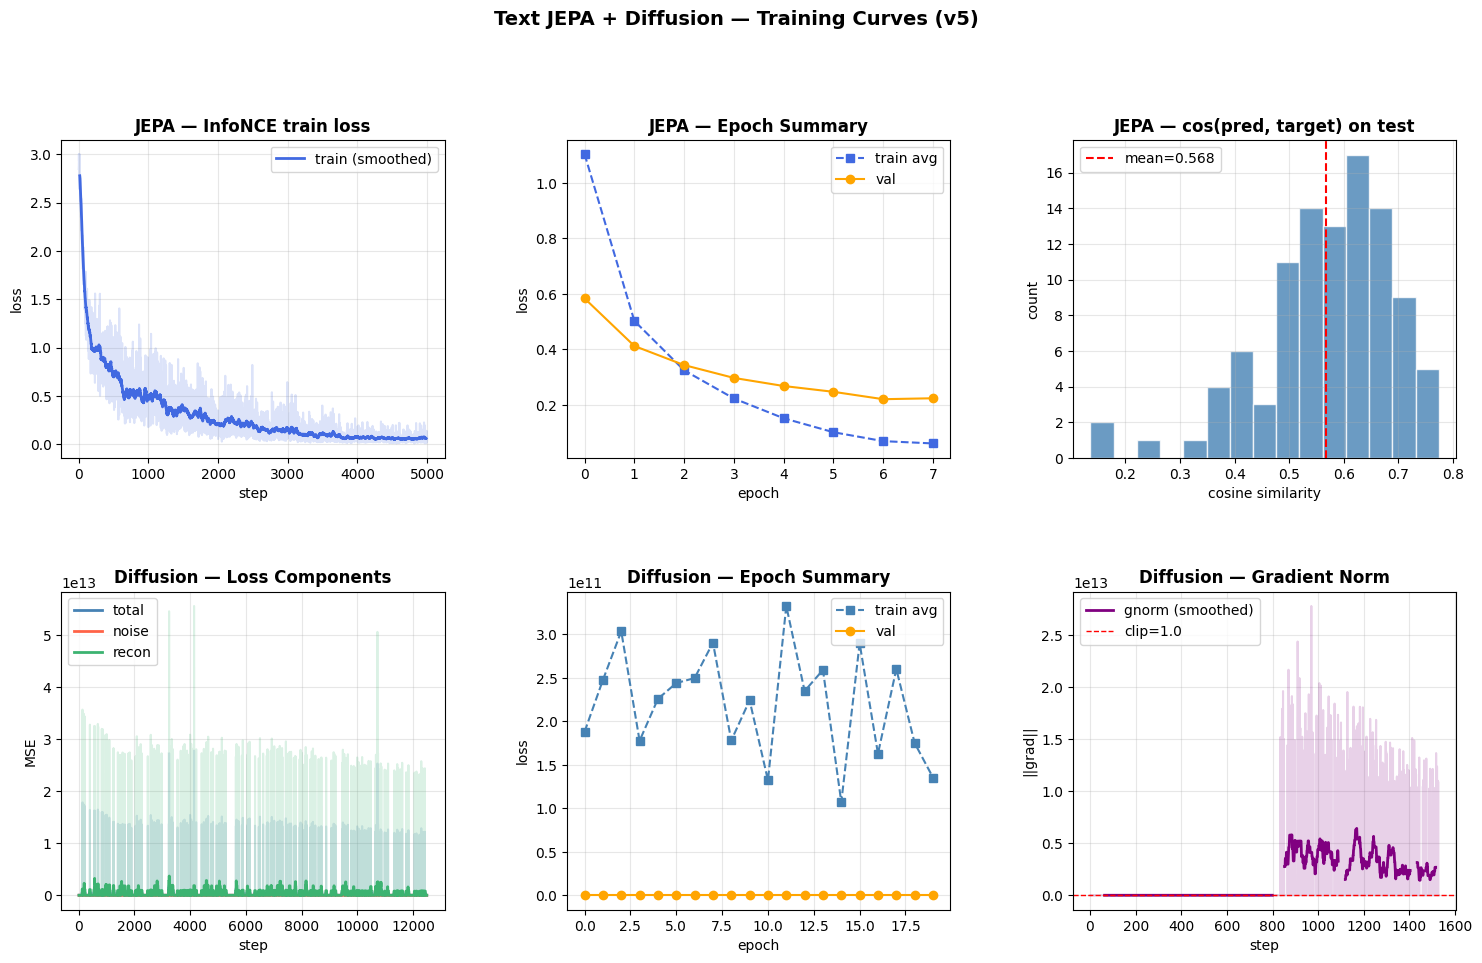


JEPA test cos-sim  mean=0.5680  std=0.1194


In [12]:
# ---------------------------------------------------------------
# loss curves
# ---------------------------------------------------------------

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)

W = 30   # smoothing window

def add_smoothed(ax, raw, color, label):
    raw = np.array(raw)
    ax.plot(raw, alpha=0.18, color=color)
    if len(raw) >= W:
        s = np.convolve(raw, np.ones(W)/W, mode='valid')
        ax.plot(np.arange(len(s)) + W//2, s, lw=2, color=color, label=label)

# --- JEPA train curve ---
ax0 = fig.add_subplot(gs[0, 0])
add_smoothed(ax0, jepa_tracker.history["train_loss"], "royalblue", "train (smoothed)")
ax0.set_title("JEPA — InfoNCE train loss", fontweight="bold")
ax0.set_xlabel("step"); ax0.set_ylabel("loss")
ax0.legend(); ax0.grid(alpha=0.3)

# --- JEPA epoch summary ---
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(jepa_tracker.history["epoch_avg"], "s--", color="royalblue", label="train avg")
ax1.plot(jepa_tracker.history["val_loss"],  "o-",  color="orange",    label="val")
ax1.set_title("JEPA — Epoch Summary", fontweight="bold")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
ax1.legend(); ax1.grid(alpha=0.3)

# --- JEPA cosine similarity (if computed) ---
ax2 = fig.add_subplot(gs[0, 2])
sims = []
predictor.eval()
with torch.no_grad():
    for i in range(min(100, len(ds["test"]))):
        doc = ds["test"][i]["document"]
        ref = ds["test"][i]["summary"]
        de  = tokenize([doc], MAX_DOC_LEN, device)
        se  = tokenize([ref], MAX_SUM_LEN, device)
        ch, cm = ctx_encoder(de)
        pe  = predictor(ch, cm)
        te  = tgt_encoder(se)
        sims.append((pe * te).sum().item())
ax2.hist(sims, bins=15, color="steelblue", edgecolor="white", alpha=0.8)
ax2.axvline(np.mean(sims), color="red", ls="--", label=f"mean={np.mean(sims):.3f}")
ax2.set_title("JEPA — cos(pred, target) on test", fontweight="bold")
ax2.set_xlabel("cosine similarity"); ax2.set_ylabel("count")
ax2.legend(); ax2.grid(alpha=0.3)

# --- Diffusion loss components ---
ax3 = fig.add_subplot(gs[1, 0])
for arr, c, lbl in [
    (diff_tracker.history["train_loss"], "steelblue",       "total"),
    (diff_tracker.history["noise_loss"], "tomato",           "noise"),
    (diff_tracker.history["recon_loss"], "mediumseagreen",   "recon"),
]:
    add_smoothed(ax3, arr, c, lbl)
ax3.set_title("Diffusion — Loss Components", fontweight="bold")
ax3.set_xlabel("step"); ax3.set_ylabel("MSE")
ax3.legend(); ax3.grid(alpha=0.3)

# --- Diffusion epoch summary ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(diff_tracker.history["epoch_avg"], "s--", color="steelblue", label="train avg")
ax4.plot(diff_tracker.history["val_loss"],  "o-",  color="orange",    label="val")
ax4.set_title("Diffusion — Epoch Summary", fontweight="bold")
ax4.set_xlabel("epoch"); ax4.set_ylabel("loss")
ax4.legend(); ax4.grid(alpha=0.3)

# --- Gradient norms ---
ax5 = fig.add_subplot(gs[1, 2])
gnorms = np.array(diff_tracker.history["gnorm"])
gnorms = gnorms[gnorms > 0]   # filter out the accumulation steps logged as 0
add_smoothed(ax5, gnorms, "purple", "gnorm (smoothed)")
ax5.axhline(1.0, color="red", ls="--", lw=1, label="clip=1.0")
ax5.set_title("Diffusion — Gradient Norm", fontweight="bold")
ax5.set_xlabel("step"); ax5.set_ylabel("||grad||")
ax5.legend(); ax5.grid(alpha=0.3)

fig.suptitle("Text JEPA + Diffusion — Training Curves (v5)", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nJEPA test cos-sim  mean={np.mean(sims):.4f}  std={np.std(sims):.4f}")